## Mô hình cơ bản được sử dụng
Nhóm thuật toán máy học cơ bản gồm:
- Linear Regression
- Logistic Regression
- Decision Tree
- K-Nearest Neighbors (KNN)

Tuy nhiên, bài toán hiện tại là dự đoán `price_vnd`, tức bài toán hồi quy. Vì vậy notebook này chỉ sử dụng các mô hình cơ bản phù hợp với hồi quy:
- Linear Regression
- Decision Tree Regressor
- KNeighbors Regressor

Logistic Regression không được dùng trong notebook này vì đây là mô hình phân loại, phù hợp hơn với bài toán dự đoán nhãn rời rạc như nhóm giá hoặc lớp nhị phân.

In [5]:
# CÀI ĐẶT THƯ VIỆN

from pathlib import Path
import re
import unicodedata
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.inspection import permutation_importance

import joblib

warnings.filterwarnings("ignore")

# Cấu hình hiển thị
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Biểu đồ
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [6]:
# PATHS

ROOT = Path(r"D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis")

MAIN_NOTEBOOK_PATH = ROOT / "Analysis_Code" / "notebooks" / "main" / "Main_Model.ipynb"
EDA_NOTEBOOK_PATH = ROOT / "Analysis_Code" / "notebooks" / "main" / "Main_EDA.ipynb"

RAW_XLSX_PATH = ROOT / "Dataset" / "raw" / "Maindataset" / "PhongTro.xlsx"
CLEANED_CSV_PATH = ROOT / "outputs" / "data" / "phongtro_cleaned.csv"

OUTPUT_DIR = ROOT / "outputs"
DATA_OUT_DIR = OUTPUT_DIR / "data"
FIG_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"
MODEL_DIR = OUTPUT_DIR / "models"

for folder in [OUTPUT_DIR, DATA_OUT_DIR, FIG_DIR, REPORT_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RAW_XLSX_PATH:", RAW_XLSX_PATH)
print("CLEANED_CSV_PATH:", CLEANED_CSV_PATH)
print("MODEL_DIR:", MODEL_DIR)

ROOT: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis
RAW_XLSX_PATH: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\Dataset\raw\Maindataset\PhongTro.xlsx
CLEANED_CSV_PATH: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\data\phongtro_cleaned.csv
MODEL_DIR: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\models


In [7]:
# HÀM TIỆN ÍCH

def print_section(title: str):
    display(Markdown(f"## {title}"))

def save_figure(fig, filename: str, dpi: int = 200):
    out_path = FIG_DIR / filename
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Đã lưu hình: {out_path}")

def strip_accents(text: str) -> str:
    if pd.isna(text):
        return np.nan
    text = str(text)
    text = unicodedata.normalize("NFD", text)
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    return unicodedata.normalize("NFC", text)

def normalize_whitespace(text: str) -> str:
    if pd.isna(text):
        return np.nan
    return re.sub(r"\s+", " ", str(text)).strip()

def clean_column_name(col: str) -> str:
    col = strip_accents(col)
    col = str(col).lower().strip()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def extract_number(value):
    if pd.isna(value):
        return np.nan
    value = str(value).lower().replace(",", ".")
    match = re.search(r"(\d+(?:\.\d+)?)", value)
    return float(match.group(1)) if match else np.nan

def normalize_location(text: str) -> str:
    if pd.isna(text):
        return np.nan
    
    raw = normalize_whitespace(text)
    no_accent = strip_accents(raw).lower()

    mapping = {
        "quan 1": "Quận 1",
        "quan 2": "Quận 2",
        "quan 3": "Quận 3",
        "quan 4": "Quận 4",
        "quan 5": "Quận 5",
        "quan 6": "Quận 6",
        "quan 7": "Quận 7",
        "quan 8": "Quận 8",
        "quan 9": "Quận 9",
        "quan 10": "Quận 10",
        "quan 11": "Quận 11",
        "quan 12": "Quận 12",
        "phu nhuan": "Phú Nhuận",
        "tan binh": "Tân Bình",
        "tan phu": "Tân Phú",
        "thu duc": "Thủ Đức",
        "go vap": "Gò Vấp",
        "binh thanh": "Bình Thạnh",
        "binh tan": "Bình Tân",
        "binh chanh": "Bình Chánh",
        "hoc mon": "Hóc Môn",
        "cu chi": "Củ Chi",
        "can gio": "Cần Giờ",
        "nha be": "Nhà Bè",
    }
    return mapping.get(no_accent, raw)

def clean_property_type(text: str) -> str:
    if pd.isna(text):
        return np.nan
    text = normalize_whitespace(text)
    mapping = {
        "PhongTro": "Phòng trọ",
        "NhaNguyenCan": "Nhà nguyên căn",
        "CanHoChungCu": "Căn hộ chung cư",
        "CanHoMini": "Căn hộ mini",
        "Studio": "Studio",
        "CanHo1PN": "Căn hộ 1PN",
        "CanHo2PN": "Căn hộ 2PN",
        "Duplex": "Duplex",
        "Penthouse": "Penthouse",
        "Shophouse": "Shophouse",
    }
    return mapping.get(text, text)

def make_keyword_flag(text_series: pd.Series, patterns: list) -> pd.Series:
    normalized = (
        text_series.fillna("")
        .astype(str)
        .apply(normalize_whitespace)
        .apply(strip_accents)
        .str.lower()
    )
    regex = "|".join(patterns)
    return normalized.str.contains(regex, regex=True, na=False)

def safe_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return mean_absolute_percentage_error(y_true[mask], y_pred[mask])

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": safe_mape(y_true, y_pred),
    }

def get_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def save_text_file(path: Path, content: str):
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)
    print(f"Đã lưu file: {path}")

In [8]:
# LOAD DỮ LIỆU

print_section("Load dữ liệu")

if CLEANED_CSV_PATH.exists():
    df = pd.read_csv(CLEANED_CSV_PATH)
    source_used = "phongtro_cleaned.csv"
else:
    if not RAW_XLSX_PATH.exists():  
        raise FileNotFoundError(f"Không tìm thấy cả cleaned CSV lẫn raw XLSX.\nChecked:\n- {CLEANED_CSV_PATH}\n- {RAW_XLSX_PATH}")
    df = pd.read_excel(RAW_XLSX_PATH, sheet_name=0)
    source_used = "raw_xlsx"

print("Nguồn dữ liệu đang dùng:", source_used)
print("Shape:", df.shape)
display(df.head())
print("Columns:", df.columns.tolist())

## Load dữ liệu

Nguồn dữ liệu đang dùng: phongtro_cleaned.csv
Shape: (1368, 20)


,tieude,dientich,giavnd,vitri,phanloai,sophong,area_m2,price_vnd,standardized_location,property_type_clean,price_per_m2,price_group,area_group,has_studio,has_balcony,has_mezzanine,has_furniture,has_new,has_window,has_elevator
0,Studio thang máy Nguyễn Thị Minh Khai gần Thảo...,40 m,8000000,Quận 1,PhongTro,1,40.0000,"8,000,000.0000",Quận 1,Phòng trọ,"200,000.0000",Trung bình (4-8.5 triệu),Vừa (25-50m²),True,False,False,False,False,False,True
1,Khai trương toà nhà mới Ngã 6 Phù Đổng,30 m,8500000,Quận 1,PhongTro,1,30.0000,"8,500,000.0000",Quận 1,Phòng trọ,"283,333.3333",Trung bình (4-8.5 triệu),Vừa (25-50m²),False,False,False,False,True,False,False
2,Phòng ban công giá rẻ gần Lý Chính Thắng,28 m,5500000,Quận 1,PhongTro,1,28.0000,"5,500,000.0000",Quận 1,Phòng trọ,"196,428.5714",Trung bình (4-8.5 triệu),Vừa (25-50m²),False,True,False,False,False,False,False
3,Phòng Studio đẹp khu Hoàng Sa,28 m,8000000,Quận 1,PhongTro,1,28.0000,"8,000,000.0000",Quận 1,Phòng trọ,"285,714.2857",Trung bình (4-8.5 triệu),Vừa (25-50m²),True,False,False,False,False,False,False
4,Phòng ban công rẻ bờ kè Hoàng Sa,25 m,5200000,Quận 1,PhongTro,1,25.0000,"5,200,000.0000",Quận 1,Phòng trọ,"208,000.0000",Trung bình (4-8.5 triệu),Nhỏ (<25m²),False,True,False,False,False,False,False


Columns: ['tieude', 'dientich', 'giavnd', 'vitri', 'phanloai', 'sophong', 'area_m2', 'price_vnd', 'standardized_location', 'property_type_clean', 'price_per_m2', 'price_group', 'area_group', 'has_studio', 'has_balcony', 'has_mezzanine', 'has_furniture', 'has_new', 'has_window', 'has_elevator']


In [9]:
# CHUẨN HÓA DỮ LIỆU CHO MODELING

print_section("Chuẩn hóa dữ liệu tối thiểu cho modeling")

# Chuẩn hóa tên cột nếu cần
df.columns = [clean_column_name(col) for col in df.columns]

# Nếu thiếu các cột đã được tạo ở notebook EDA, tự bổ sung ở đây
if "area_m2" not in df.columns:
    if "dientich" in df.columns:
        df["area_m2"] = df["dientich"].apply(extract_number)
    else:
        raise ValueError("Không tìm thấy cột area_m2 hoặc dientich.")

if "price_vnd" not in df.columns:
    if "giavnd" in df.columns:
        df["price_vnd"] = pd.to_numeric(df["giavnd"], errors="coerce")
    else:
        raise ValueError("Không tìm thấy cột price_vnd hoặc giavnd.")

if "standardized_location" not in df.columns:
    if "vitri" in df.columns:
        df["standardized_location"] = df["vitri"].apply(normalize_location)
    else:
        raise ValueError("Không tìm thấy cột standardized_location hoặc vitri.")

if "property_type_clean" not in df.columns:
    if "phanloai" in df.columns:
        df["property_type_clean"] = df["phanloai"].apply(clean_property_type)
    else:
        raise ValueError("Không tìm thấy cột property_type_clean hoặc phanloai.")

if "area_group" not in df.columns:
    df["area_group"] = pd.cut(
        df["area_m2"],
        bins=[0, 25, 50, np.inf],
        labels=["Nhỏ (<25m²)", "Vừa (25-50m²)", "Lớn (>50m²)"],
        include_lowest=True
    )

# Tạo keyword flags nếu chưa có
keyword_patterns = {
    "has_studio": [r"\bstudio\b"],
    "has_balcony": [r"ban cong", r"balcony"],
    "has_mezzanine": [r"gac lung", r"mezzanine", r"\bloft\b"],
    "has_furniture": [r"noi that", r"full noi that", r"furnished"],
    "has_new": [r"moi xay", r"khai truong", r"\bnew\b"],
    "has_window": [r"cua so", r"window"],
    "has_elevator": [r"thang may", r"elevator"],
}

if "tieude" in df.columns:
    for col_name, patterns in keyword_patterns.items():
        if col_name not in df.columns:
            df[col_name] = make_keyword_flag(df["tieude"], patterns)

# Chuẩn hóa kiểu dữ liệu
if "sophong" in df.columns:
    df["sophong"] = pd.to_numeric(df["sophong"], errors="coerce")

for col in keyword_patterns.keys():
    if col in df.columns:
        df[col] = df[col].astype(int)

# Bỏ dòng target thiếu hoặc feature nền vô lý
df_model = df.copy()
df_model = df_model.dropna(subset=["price_vnd", "area_m2"]).copy()
df_model = df_model[df_model["price_vnd"] > 0].copy()
df_model = df_model[df_model["area_m2"] > 0].copy()

print("Shape sau chuẩn hóa modeling:", df_model.shape)
display(df_model.head())

## Chuẩn hóa dữ liệu tối thiểu cho modeling

Shape sau chuẩn hóa modeling: (1368, 20)


,tieude,dientich,giavnd,vitri,phanloai,sophong,area_m2,price_vnd,standardized_location,property_type_clean,price_per_m2,price_group,area_group,has_studio,has_balcony,has_mezzanine,has_furniture,has_new,has_window,has_elevator
0,Studio thang máy Nguyễn Thị Minh Khai gần Thảo...,40 m,8000000,Quận 1,PhongTro,1,40.0000,"8,000,000.0000",Quận 1,Phòng trọ,"200,000.0000",Trung bình (4-8.5 triệu),Vừa (25-50m²),1,0,0,0,0,0,1
1,Khai trương toà nhà mới Ngã 6 Phù Đổng,30 m,8500000,Quận 1,PhongTro,1,30.0000,"8,500,000.0000",Quận 1,Phòng trọ,"283,333.3333",Trung bình (4-8.5 triệu),Vừa (25-50m²),0,0,0,0,1,0,0
2,Phòng ban công giá rẻ gần Lý Chính Thắng,28 m,5500000,Quận 1,PhongTro,1,28.0000,"5,500,000.0000",Quận 1,Phòng trọ,"196,428.5714",Trung bình (4-8.5 triệu),Vừa (25-50m²),0,1,0,0,0,0,0
3,Phòng Studio đẹp khu Hoàng Sa,28 m,8000000,Quận 1,PhongTro,1,28.0000,"8,000,000.0000",Quận 1,Phòng trọ,"285,714.2857",Trung bình (4-8.5 triệu),Vừa (25-50m²),1,0,0,0,0,0,0
4,Phòng ban công rẻ bờ kè Hoàng Sa,25 m,5200000,Quận 1,PhongTro,1,25.0000,"5,200,000.0000",Quận 1,Phòng trọ,"208,000.0000",Trung bình (4-8.5 triệu),Nhỏ (<25m²),0,1,0,0,0,0,0


In [10]:
# CHỌN ĐẶC TRƯNG 

print_section("Feature selection và kiểm soát target leakage")

# Không dùng các biến dẫn xuất từ target
leakage_cols = [
    "price_vnd",
    "price_per_m2",   # price / area => chứa target
    "price_group",    # phân nhóm trực tiếp từ target
    "giavnd"
]

candidate_numeric = ["area_m2", "sophong"]
candidate_categorical = ["standardized_location", "property_type_clean", "area_group"]
candidate_binary = list(keyword_patterns.keys())

numeric_features = [c for c in candidate_numeric if c in df_model.columns]
categorical_features = [c for c in candidate_categorical if c in df_model.columns]
binary_features = [c for c in candidate_binary if c in df_model.columns]

feature_columns = numeric_features + categorical_features + binary_features
target_col = "price_vnd"

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Binary features:", binary_features)
print("Target:", target_col)

explanation_df = pd.DataFrame({
    "feature_group": ["Numeric", "Categorical", "Binary keyword flags", "Excluded to avoid leakage"],
    "columns": [
        ", ".join(numeric_features) if numeric_features else "(none)",
        ", ".join(categorical_features) if categorical_features else "(none)",
        ", ".join(binary_features) if binary_features else "(none)",
        ", ".join([c for c in leakage_cols if c in df_model.columns]) if [c for c in leakage_cols if c in df_model.columns] else "(none)"
    ],
    "reason": [
        "Biến cấu trúc nền của bất động sản, có ý nghĩa định lượng.",
        "Biến vị trí và loại hình giúp mô hình học khác biệt theo phân khúc/khu vực.",
        "Keyword từ tiêu đề phản ánh tiện ích/mô tả sản phẩm.",
        "Các biến này chứa trực tiếp hoặc gián tiếp thông tin của target, gây target leakage."
    ]
})
display(explanation_df)

## Feature selection và kiểm soát target leakage

Numeric features: ['area_m2', 'sophong']
Categorical features: ['standardized_location', 'property_type_clean', 'area_group']
Binary features: ['has_studio', 'has_balcony', 'has_mezzanine', 'has_furniture', 'has_new', 'has_window', 'has_elevator']
Target: price_vnd


,feature_group,columns,reason
0,Numeric,"area_m2, sophong","Biến cấu trúc nền của bất động sản, có ý nghĩa..."
1,Categorical,"standardized_location, property_type_clean, ar...",Biến vị trí và loại hình giúp mô hình học khác...
2,Binary keyword flags,"has_studio, has_balcony, has_mezzanine, has_fu...",Keyword từ tiêu đề phản ánh tiện ích/mô tả sản...
3,Excluded to avoid leakage,"price_vnd, price_per_m2, price_group, giavnd",Các biến này chứa trực tiếp hoặc gián tiếp thô...


In [11]:
# TRAIN / TEST SPLIT

print_section("Chia train / test")

X = df_model[feature_columns].copy()
y = df_model[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

## Chia train / test

X_train: (1094, 12)
X_test : (274, 12)
y_train: (1094,)
y_test : (274,)


In [12]:
# TIỀN XỬ LÝ XỬ LIỆU

print_section("Preprocessing pipeline")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", get_onehot_encoder())
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", binary_transformer, binary_features),
    ],
    remainder="drop"
)

preprocessor

## Preprocessing pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [ ]:
# MODEL CATALOG - BASIC MODELS ONLY

print_section("Danh sách mô hình cơ bản")

model_catalog = {
    "Dummy_Median": DummyRegressor(strategy="median"),
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(
        random_state=RANDOM_SEED,
        max_depth=8,
        min_samples_leaf=5
    ),
    "KNN": KNeighborsRegressor(
        n_neighbors=7,
        weights="distance",
        metric="minkowski",
        p=2
    ),
}

model_reason = {
    "Dummy_Median": (
        "Baseline kỹ thuật để kiểm tra liệu các mô hình học máy có thực sự học tốt hơn "
        "một dự đoán hằng số hay không."
    ),
    "LinearRegression": (
        "Là mô hình hồi quy cơ bản nhất, phù hợp khi muốn kiểm tra quan hệ tuyến tính giữa "
        "các biến đầu vào và giá thuê. Mô hình dễ diễn giải và là chuẩn so sánh đầu tiên."
    ),
    "DecisionTree": (
        "Là mô hình cơ bản có thể dùng cho hồi quy, phù hợp khi dữ liệu có quan hệ phi tuyến "
        "và có các ngưỡng chia tách rõ giữa các nhóm bất động sản."
    ),
    "KNN": (
        "Là mô hình cơ bản dựa trên khoảng cách, phù hợp khi muốn dự đoán giá dựa trên các tin đăng "
        "có đặc điểm gần giống nhau trong không gian đặc trưng."
    ),
}

model_type_df = pd.DataFrame({
    "model": list(model_catalog.keys()),
    "role": [
        "Baseline kỹ thuật",
        "Mô hình cơ bản theo slide",
        "Mô hình cơ bản theo slide",
        "Mô hình cơ bản theo slide",
    ],
    "why_selected": [model_reason[name] for name in model_catalog.keys()]
})

display(model_type_df)

## Danh sách mô hình cơ bản

,model,role,why_selected
0,Dummy_Median,Baseline kỹ thuật,Baseline kỹ thuật để kiểm tra liệu các mô hình...
1,LinearRegression,Mô hình cơ bản theo slide,"Là mô hình hồi quy cơ bản nhất, phù hợp khi mu..."
2,DecisionTree,Mô hình cơ bản theo slide,"Là mô hình cơ bản có thể dùng cho hồi quy, phù..."
3,KNN,Mô hình cơ bản theo slide,"Là mô hình cơ bản dựa trên khoảng cách, phù hợ..."


In [ ]:
# MODELING JUSTIFICATION

print_section("Giải thích vì sao chọn các mô hình này")

justification_text = """
Bộ mô hình trong notebook này được giới hạn theo đúng nhóm thuật toán cơ bản trong tài liệu môn học.
Vì bài toán hiện tại là dự đoán giá thuê (biến liên tục), notebook chỉ giữ lại các mô hình cơ bản phù hợp với hồi quy:

1. Linear Regression:
   - Dùng làm mô hình chuẩn để kiểm tra mức độ tuyến tính giữa feature và giá thuê.
   - Ưu điểm: đơn giản, dễ diễn giải.
   - Hạn chế: khó bắt các quan hệ phi tuyến phức tạp.

2. Decision Tree Regressor:
   - Phù hợp khi dữ liệu có các ngưỡng chia tách tự nhiên.
   - Có thể mô hình hóa tương tác giữa feature mà không cần giả định tuyến tính.
   - Hạn chế: dễ overfit nếu không kiểm soát độ sâu cây.

3. KNeighbors Regressor:
   - Phù hợp khi các quan sát có tính cục bộ, nghĩa là tin đăng gần nhau trong không gian đặc trưng thường có mức giá gần nhau.
   - Nhạy với scale dữ liệu, vì vậy cần standardize feature numeric.
   - Hạn chế: giảm hiệu quả nếu dữ liệu nhiễu hoặc số chiều tăng cao.

4. DummyRegressor:
   - Không nằm trong nhóm mô hình học thuật của slide, nhưng cần dùng làm baseline kỹ thuật.
   - Mục đích: xem mô hình học máy có thực sự tốt hơn một dự đoán median đơn giản hay không.
"""

print(justification_text)

## Giải thích vì sao chọn các mô hình này


Bộ mô hình trong notebook này được giới hạn theo đúng nhóm thuật toán cơ bản trong tài liệu môn học.
Vì bài toán hiện tại là dự đoán giá thuê (biến liên tục), notebook chỉ giữ lại các mô hình cơ bản phù hợp với hồi quy:

1. Linear Regression:
   - Dùng làm mô hình chuẩn để kiểm tra mức độ tuyến tính giữa feature và giá thuê.
   - Ưu điểm: đơn giản, dễ diễn giải.
   - Hạn chế: khó bắt các quan hệ phi tuyến phức tạp.

2. Decision Tree Regressor:
   - Phù hợp khi dữ liệu có các ngưỡng chia tách tự nhiên.
   - Có thể mô hình hóa tương tác giữa feature mà không cần giả định tuyến tính.
   - Hạn chế: dễ overfit nếu không kiểm soát độ sâu cây.

3. KNeighbors Regressor:
   - Phù hợp khi các quan sát có tính cục bộ, nghĩa là tin đăng gần nhau trong không gian đặc trưng thường có mức giá gần nhau.
   - Nhạy với scale dữ liệu, vì vậy cần standardize feature numeric.
   - Hạn chế: giảm hiệu quả nếu dữ liệu nhiễu hoặc số chiều tăng cao.

4. DummyRegressor:
   - Không nằm trong nhóm mô hình học thu

In [ ]:
#  BUILD ESTIMATOR & EVALUATION

print_section("Hàm dựng estimator")

def make_estimator(base_model):
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", base_model)
    ])
    
    estimator = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )
    return estimator

print_section("Thiết lập đánh giá")

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

def evaluate_with_cv(model_name, model_obj, X_train, y_train):
    estimator = make_estimator(model_obj)

    cv_result = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    return {
        "model": model_name,
        "cv_mae_mean": -cv_result["test_MAE"].mean(),
        "cv_mae_std": cv_result["test_MAE"].std(),
        "cv_rmse_mean": -cv_result["test_RMSE"].mean(),
        "cv_rmse_std": cv_result["test_RMSE"].std(),
        "cv_r2_mean": cv_result["test_R2"].mean(),
        "cv_r2_std": cv_result["test_R2"].std(),
    }


## Hàm dựng estimator

## Thiết lập đánh giá

In [ ]:
# CROSS-VALIDATION 

print_section("So sánh cross-validation giữa các mô hình cơ bản")

cv_results = []

for model_name, model_obj in model_catalog.items():
    print(f"Đang đánh giá: {model_name}")
    result = evaluate_with_cv(model_name, model_obj, X_train, y_train)
    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by=["cv_rmse_mean", "cv_mae_mean"],
    ascending=[True, True]
).reset_index(drop=True)

display(cv_results_df)

cv_report_path = REPORT_DIR / "basic_model_cv_comparison.csv"
cv_results_df.to_csv(cv_report_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu: {cv_report_path}")

## So sánh cross-validation giữa các mô hình cơ bản

Đang đánh giá: Dummy_Median
Đang đánh giá: LinearRegression
Đang đánh giá: DecisionTree
Đang đánh giá: KNN


,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,LinearRegression,"2,442,446.9807","275,843.7019","5,587,168.8002","1,293,603.7593",0.4165,0.1064
1,DecisionTree,"2,604,740.1573","338,618.4560","5,816,100.3484","1,436,992.7365",0.3621,0.1725
2,KNN,"2,565,859.8920","292,766.3814","5,859,987.1441","1,369,491.2709",0.3609,0.0933
3,Dummy_Median,"3,631,260.5935","283,822.5488","7,494,681.0068","1,314,545.0530",-0.0592,0.0129


Đã lưu: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\reports\basic_model_cv_comparison.csv


## Trực quan hóa kết quả CV

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\basic_model_cv_comparison.png


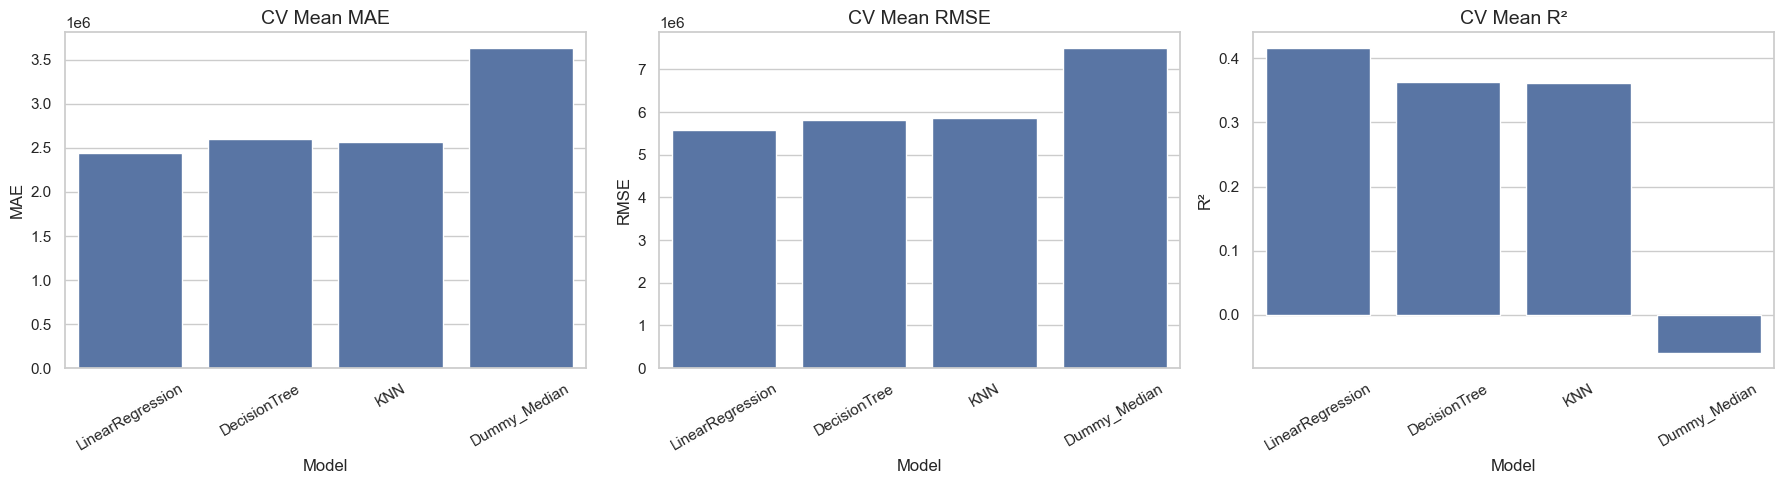

In [ ]:
# CV VISUALIZATION

print_section("Trực quan hóa kết quả CV")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=cv_results_df, x="model", y="cv_mae_mean", ax=axes[0])
axes[0].set_title("CV Mean MAE")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=cv_results_df, x="model", y="cv_rmse_mean", ax=axes[1])
axes[1].set_title("CV Mean RMSE")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=cv_results_df, x="model", y="cv_r2_mean", ax=axes[2])
axes[2].set_title("CV Mean R²")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=30)

save_figure(fig, "basic_model_cv_comparison.png")
plt.show()

In [ ]:
# HOLD-OUT TEST EVALUATION

print_section("Đánh giá trên hold-out test set")

trained_models = {}
test_results = []

for model_name, model_obj in model_catalog.items():
    print(f"Đang train/test: {model_name}")
    estimator = make_estimator(model_obj)
    estimator.fit(X_train, y_train)

    y_pred_test = estimator.predict(X_test)
    metrics = regression_metrics(y_test, y_pred_test)

    test_results.append({
        "model": model_name,
        "test_mae": metrics["MAE"],
        "test_rmse": metrics["RMSE"],
        "test_r2": metrics["R2"],
        "test_mape": metrics["MAPE"],
    })

    trained_models[model_name] = estimator

test_results_df = pd.DataFrame(test_results).sort_values(
    by=["test_rmse", "test_mae"],
    ascending=[True, True]
).reset_index(drop=True)

display(test_results_df)

test_report_path = REPORT_DIR / "basic_model_test_comparison.csv"
test_results_df.to_csv(test_report_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu: {test_report_path}")

## Đánh giá trên hold-out test set

Đang train/test: Dummy_Median
Đang train/test: LinearRegression
Đang train/test: DecisionTree
Đang train/test: KNN


,model,test_mae,test_rmse,test_r2,test_mape
0,DecisionTree,"2,749,701.5098","6,867,939.9926",0.3704,0.3608
1,LinearRegression,"2,624,296.4203","6,994,392.1593",0.3470,0.3951
2,KNN,"2,933,951.2623","7,068,085.4033",0.3332,0.4459
3,Dummy_Median,"4,028,503.6496","8,910,512.7569",-0.0597,0.7342


Đã lưu: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\reports\basic_model_test_comparison.csv


In [19]:
# MERGE CV + TEST RESULTS

print_section("Bảng tổng hợp kết quả")

comparison_df = cv_results_df.merge(test_results_df, on="model", how="left")
comparison_df = comparison_df.sort_values(by=["cv_rmse_mean", "test_rmse"]).reset_index(drop=True)

display(comparison_df)

comparison_path = REPORT_DIR / "basic_model_comparison_full.csv"
comparison_df.to_csv(comparison_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu: {comparison_path}")

## Bảng tổng hợp kết quả

,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,test_mae,test_rmse,test_r2,test_mape
0,LinearRegression,"2,442,446.9807","275,843.7019","5,587,168.8002","1,293,603.7593",0.4165,0.1064,"2,624,296.4203","6,994,392.1593",0.3470,0.3951
1,DecisionTree,"2,604,740.1573","338,618.4560","5,816,100.3484","1,436,992.7365",0.3621,0.1725,"2,749,701.5098","6,867,939.9926",0.3704,0.3608
2,KNN,"2,565,859.8920","292,766.3814","5,859,987.1441","1,369,491.2709",0.3609,0.0933,"2,933,951.2623","7,068,085.4033",0.3332,0.4459
3,Dummy_Median,"3,631,260.5935","283,822.5488","7,494,681.0068","1,314,545.0530",-0.0592,0.0129,"4,028,503.6496","8,910,512.7569",-0.0597,0.7342


Đã lưu: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\reports\basic_model_comparison_full.csv


In [ ]:
# FINAL MODEL SELECTION

print_section("Chọn mô hình tốt nhất trong nhóm cơ bản")

best_model_name = comparison_df.iloc[0]["model"]
final_model = trained_models[best_model_name]

print("Best basic model:", best_model_name)
# =========================
# FINAL MODEL EVALUATION
# =========================

print_section("Đánh giá chi tiết mô hình tốt nhất")

y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)

train_metrics = regression_metrics(y_train, y_pred_train)
test_metrics = regression_metrics(y_test, y_pred_test)

final_eval_df = pd.DataFrame([
    {"dataset": "train", **train_metrics},
    {"dataset": "test", **test_metrics},
])

display(final_eval_df)

final_eval_path = REPORT_DIR / "basic_final_model_metrics.csv"
final_eval_df.to_csv(final_eval_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu: {final_eval_path}")

## Chọn mô hình tốt nhất trong nhóm cơ bản

Best basic model: LinearRegression


## Đánh giá chi tiết mô hình tốt nhất

,dataset,MAE,RMSE,R2,MAPE
0,train,"2,336,882.3335","5,605,439.4005",0.4264,0.3294
1,test,"2,624,296.4203","6,994,392.1593",0.3470,0.3951


Đã lưu: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\reports\basic_final_model_metrics.csv


In [ ]:
# FINAL MODEL SELECTION


print_section("Chọn mô hình tốt nhất trong nhóm cơ bản")

best_model_name = comparison_df.iloc[0]["model"]
final_model = trained_models[best_model_name]

print("Best basic model:", best_model_name)

## Chọn mô hình tốt nhất trong nhóm cơ bản

Best basic model: LinearRegression


## Actual vs Predicted

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\basic_final_actual_vs_predicted.png


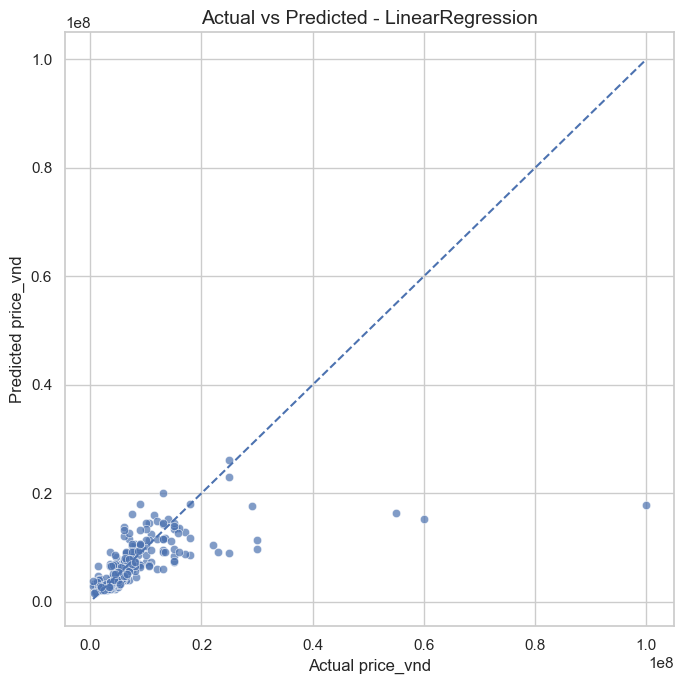

In [ ]:
# ACTUAL VS PREDICTED

print_section("Actual vs Predicted")

fig, ax = plt.subplots(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.7, ax=ax)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

ax.set_title(f"Actual vs Predicted - {best_model_name}")
ax.set_xlabel("Actual price_vnd")
ax.set_ylabel("Predicted price_vnd")

save_figure(fig, "basic_final_actual_vs_predicted.png")
plt.show()

## Residual analysis

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\basic_final_residual_analysis.png


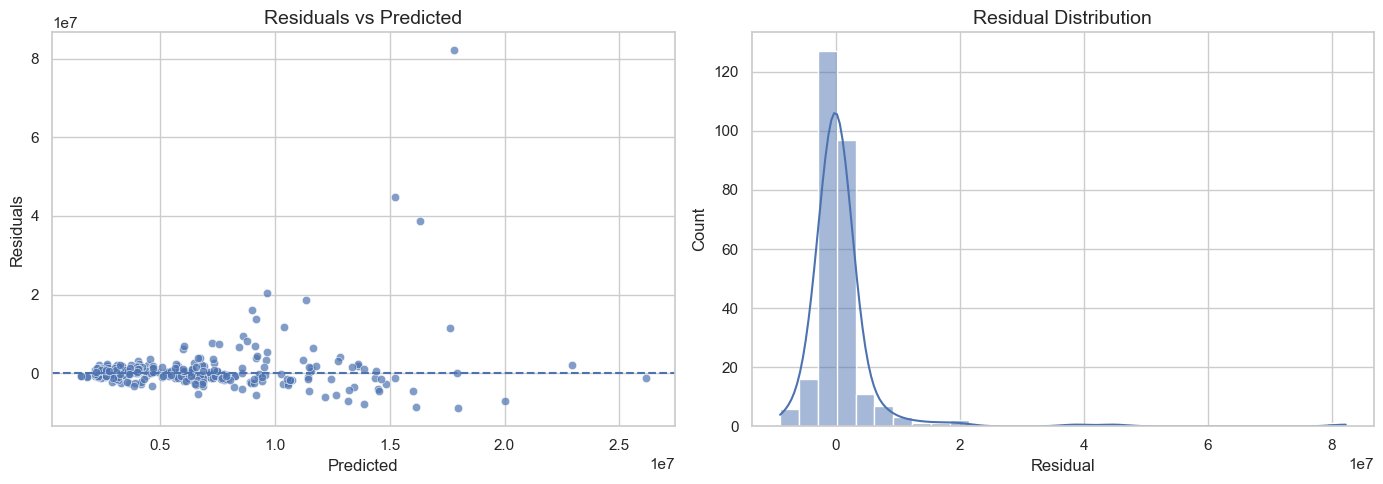

In [ ]:
# RESIDUAL ANALYSIS

print_section("Residual analysis")

residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.7, ax=axes[0])
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

save_figure(fig, "basic_final_residual_analysis.png")
plt.show()

## Permutation importance

,feature,importance_mean,importance_std
3,property_type_clean,"959,356.2889","168,351.6086"
0,area_m2,"722,373.2118","45,259.9859"
4,area_group,"480,211.3385","75,165.7027"
2,standardized_location,"422,194.0486","154,443.4017"
1,sophong,"100,682.0650","19,171.0044"
7,has_mezzanine,"1,861.7100","4,373.8909"
11,has_elevator,-247.6532,265.4812
9,has_new,"-1,729.0396","4,265.3820"
10,has_window,"-3,360.6232","9,220.5221"
6,has_balcony,"-28,137.4229","50,899.5056"


Đã lưu: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\reports\basic_final_permutation_importance.csv
Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\basic_final_top20_importance.png


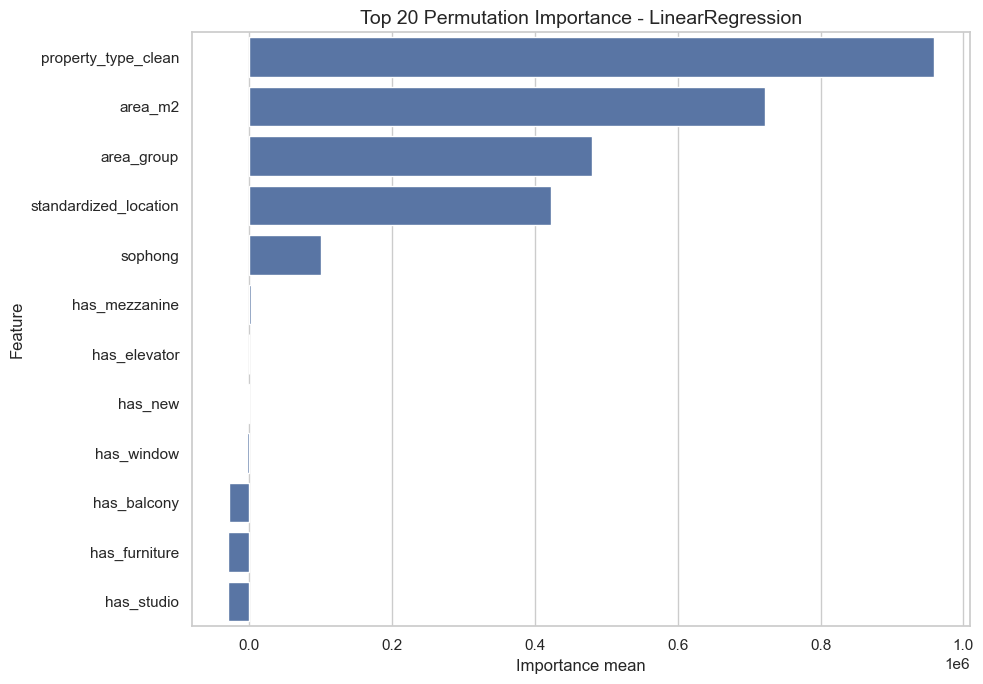

In [ ]:
# PERMUTATION IMPORTANCE

print_section("Permutation importance")

perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(20))

importance_path = REPORT_DIR / "basic_final_permutation_importance.csv"
importance_df.to_csv(importance_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu: {importance_path}")

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importance_df.head(20), x="importance_mean", y="feature", ax=ax)
ax.set_title(f"Top 20 Permutation Importance - {best_model_name}")
ax.set_xlabel("Importance mean")
ax.set_ylabel("Feature")

save_figure(fig, "basic_final_top20_importance.png")
plt.show()

In [26]:
# =========================
# SAVE MODEL & PREDICTIONS
# =========================

print_section("Lưu model và dự đoán")

pred_df = X_test.copy()
pred_df["actual_price_vnd"] = y_test.values
pred_df["predicted_price_vnd"] = y_pred_test
pred_df["residual"] = pred_df["actual_price_vnd"] - pred_df["predicted_price_vnd"]
pred_df["abs_error"] = np.abs(pred_df["residual"])

pred_path = DATA_OUT_DIR / "basic_final_model_test_predictions.csv"
pred_df.to_csv(pred_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu predictions: {pred_path}")

model_path = MODEL_DIR / f"{best_model_name}_basic_final.joblib"
joblib.dump(final_model, model_path)
print(f"Đã lưu model: {model_path}")

## Lưu model và dự đoán

Đã lưu predictions: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\data\basic_final_model_test_predictions.csv
Đã lưu model: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\models\LinearRegression_basic_final.joblib
